In [1]:
from pathlib import Path
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from pytorch_lightning.core.lightning import LightningModule
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.chdir('/home/kai/DigitalICU/Experiments/HIRID-PatientStateSpace/')

from utils.config_dataset import *
from utils.ClassDataset import MergedDataset
from utils.ClassSOM import SOM_PRED

RANDOMSEED = 2024
torch.manual_seed(RANDOMSEED)
np.random.seed(RANDOMSEED)

def mae_loss(x_, x, los=False):
    if los:
        loss = np.mean(np.abs(x - x_))
    else:
        mask_valid = np.where(x!=-1)
        loss = np.mean(np.abs(x[mask_valid] - x_[mask_valid]))
    return loss

In [77]:
norm_params = pickle.load(open('processed-merge/norm_params_vasopressor.p', 'rb'))

def de_norm(data, col, norm_params=norm_params):
    norm_min = norm_params[col].loc['0.1%']
    norm_max = norm_params[col].loc['99.9%']
    data_ = data * (norm_max - norm_min) + norm_min
    return data_

In [58]:
model_path = 'models/SOM_PRED/CNN-196hidden-8som-3r-0.1dropout-8-0.0005/version_0'
model_file = os.path.join(model_path, "epoch94-val_loss0.58486.ckpt")
config_file = os.path.join(model_path, "model_config.p")

device = 'cuda'

 # load data
print("Loading dataset")
data_path = 'processed-merge/'
pid_valid = pickle.load(open(os.path.join(data_path, 'pid_valid_00.p'), 'rb'))
patient_info = pickle.load(open(os.path.join(data_path, 'patient_info.p'), 'rb'))
sample_dict = pickle.load(open(os.path.join(data_path, 'sample_dict_vasopressor.p'), 'rb'))
norm_params = pickle.load(open('processed-merge/norm_params_vasopressor.p', 'rb'))
norm_params_info = pickle.load(open('processed-merge/norm_params_info_vasopressor.p', 'rb'))

dischargestatus = []
for i in sample_dict:
    status = patient_info.loc[patient_info['patientid'] == sample_dict[i][1], 'discharge_status'].item()
    label = 1 if status == 'dead' else 0
    dischargestatus.append(label)
dischargestatus = np.array(dischargestatus)

selected_physio = ['HR', 'RR', 'SpO2', 'ABPd', 'ABPm', 'ABPs', 'ZVD']
selected_med = ['norepinephrine', 'epinephrine', 'dobutamine']
train_test_indices = pickle.load(open(os.path.join(data_path, 'train_test_split_vasopressor.p'), 'rb'))
sampleid_train, sampleid_test = train_test_indices['train'], train_test_indices['test']
sampleid_tr, sampleid_val = train_test_split(sampleid_train, test_size=0.2, random_state=RANDOMSEED,
                                   stratify=dischargestatus[sampleid_train])

dataset_val = MergedDataset(sample_dict={item[0]: item[1] for item in sample_dict.items() if item[0] in sampleid_val},
                              df_info=patient_info, norm=True, selected_physio=selected_physio,selected_med=selected_med)
dataset_test = MergedDataset(sample_dict={item[0]: item[1] for item in sample_dict.items() if item[0] in sampleid_test},
                              df_info=patient_info, norm=True, selected_physio=selected_physio,selected_med=selected_med)
loader_val = DataLoader(dataset_val, batch_size=16, shuffle=False, num_workers=32)
loader_test = DataLoader(dataset_test, batch_size=16, shuffle=False, num_workers=16)

# Train model
config = pickle.load(open(config_file, 'rb'))

model = SOM_PRED.load_from_checkpoint(checkpoint_path=model_file, config=config)
model.to(device)
model.eval()

X_reconstructed = []
X_pred = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    X_, X_next = model(X)
    X_reconstructed.append(X_.cpu().detach().numpy())
    X_pred.append(X_next.cpu().detach().numpy())
    
X_reconstructed = np.concatenate(X_reconstructed, axis=0)
X_pred = np.concatenate(X_pred, axis=0)

Loading dataset


/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
100%|███████████████████| 50/50 [00:01<00:00, 36.11it/s]


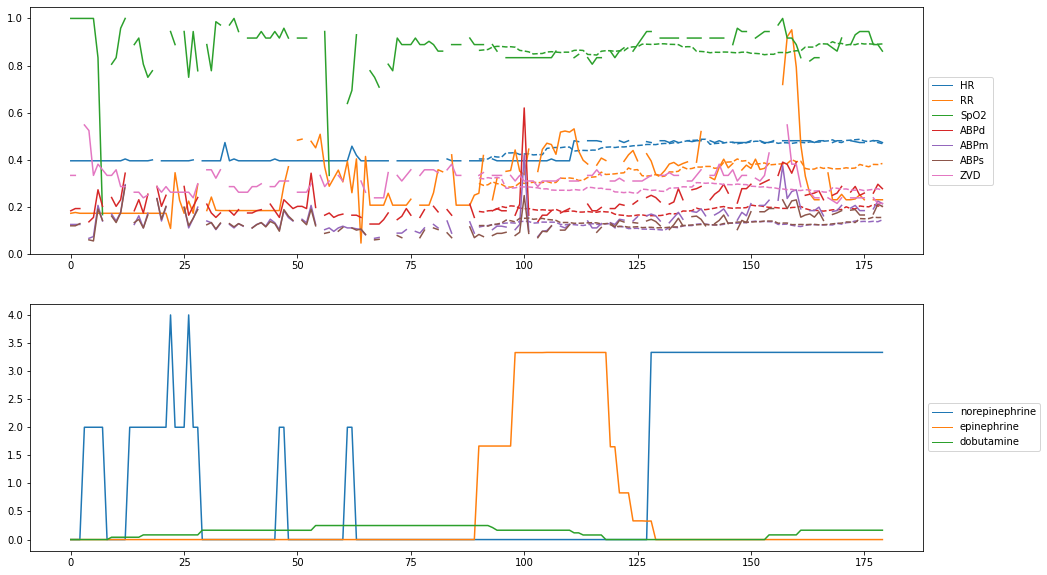

In [110]:
idx = 456
# idx = 15

x = dataset_test[idx]['data']
x[np.where(x==-1)] = np.nan
x_ = X_reconstructed[idx]
x_[np.where(x_==-1)] = np.nan
x_next = X_pred[idx]
x_next[np.where(x_next==-1)] = np.nan
x_med = dataset_test[idx]['med']
x_med[np.where(x_med)==0] = np.nan

labels = selected_physio

fig, ax = plt.subplots(2,1,figsize=(16,10))
colors = plt.cm.tab10
for j in range(7):
    ax[0].plot(range(180), x[:,j], '-', color=colors(j))
#     ax.plot(range(90), x_[:,j], '--', color=colors(j))
    ax[0].plot(range(90, 180), x_next[:,j], '--', color=colors(j))

lines = [Line2D([0], [0], color=colors(i), lw=1, label=labels[i]) for i in range(7)]
ax[0].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));


lines = []
for med in MED_BENCHMARK[:3]:
    idx_med = MED_BENCHMARK.index(med)
    med_raw =  de_norm(x_med[:, idx_med], med)
    ax[1].plot(med_raw, label=med, color=colors(idx_med))
    lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
ax[1].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));

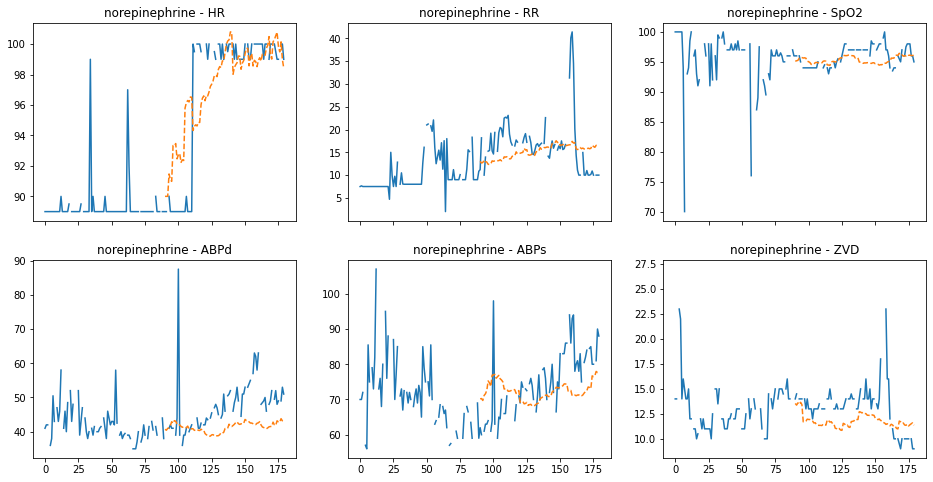

In [112]:
# idx = 30
# idx = 66
# idx = 15
idx = 456


x = dataset_test[idx]['data']
x[np.where(x==-1)] = np.nan
x_ = X_reconstructed[idx]
x_[np.where(x_==-1)] = np.nan
x_next = X_pred[idx]
x_next[np.where(x_next==-1)] = np.nan
meds = ['norepinephrine', 'epinephrine', 'dobutamine']
med = meds[np.where(sample['med_label']==1)[0].item()]

labels = selected_physio

fig, ax = plt.subplots(2,3,figsize=(16,8), sharex=True)
colors = plt.cm.tab10
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPd',
    'ABPs',
    'ZVD',
]
for i, physio in enumerate(physio_plot):
    idx_physio = PHYSIO_BENCHMARK.index(physio)
    
    x_raw = de_norm(x[:,idx_physio], physio)
    x_pred = de_norm(x_next[:,idx_physio], physio)
    
    ax[i//3][i%3].plot(range(180), x_raw, '-', color=colors(0))
    ax[i//3][i%3].plot(range(90, 180), x_pred, '--', color=colors(1))
    ax[i//3][i%3].set_title(f"{med} - {physio}")


# lines = [Line2D([0], [0], color=colors(i), lw=1, label=labels[i]) for i in range(7)]
# plt.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));

# Response for different vasoactive agents

In [59]:
meds = ['norepinephrine', 'epinephrine', 'dobutamine',]

data_raw = {med: [] for med in meds}
data_pred = {med: [] for med in meds}
for idx, sample in enumerate(dataset_test):
    med = meds[np.where(sample['med_label']==1)[0].item()]
    raw = sample['data']
    raw[np.where(raw==-1)] = np.nan
    data_raw[med].append(raw[None,:,:])
    data_pred[med].append(np.concatenate((X_reconstructed[idx], X_pred[idx]), axis=0)[None,:,:])

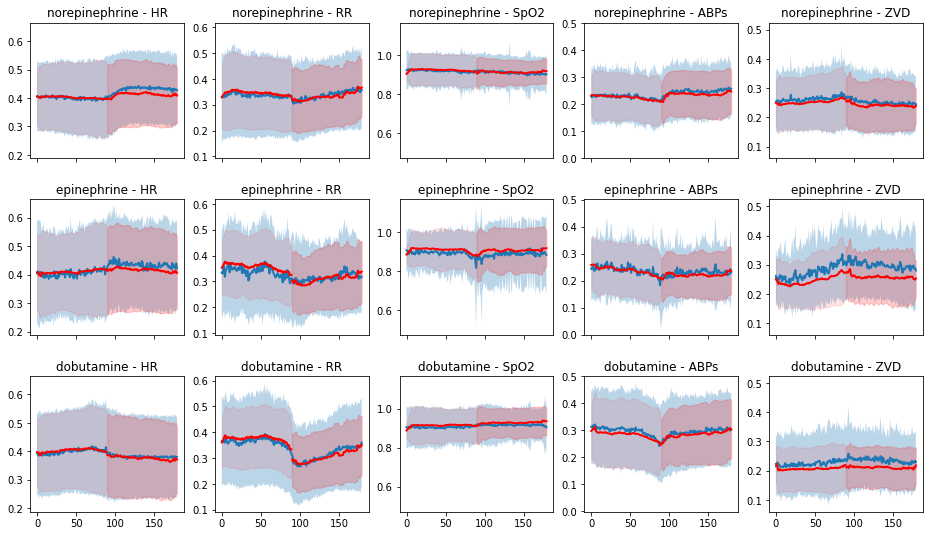

In [71]:
fig, ax = plt.subplots(3, 5, figsize=(16,9), sharex=True, sharey='col')
plt.subplots_adjust(hspace=.3, wspace=.2)
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPs',
    'ZVD',
#     'OUTurine/h',
]


for i, med in enumerate(MED_BENCHMARK[:3]):
    data = np.concatenate(data_raw[med], axis=0)
    mean_raw = np.nanmean(data, axis=0)
    std_raw = np.nanstd(data, axis=0)

    pred = np.concatenate(data_pred[med], axis=0)
    mean = pred.mean(0)
    std = pred.std(0)
    for j, physio in enumerate(physio_plot):
        idx_physio = PHYSIO_BENCHMARK.index(physio)
        
        
        ax[i][j].plot(mean_raw[:,idx_physio], linewidth=2);
        ax[i][j].fill_between(range(180), 
                        mean_raw[:,idx_physio]-std_raw[:,idx_physio], 
                        mean_raw[:,idx_physio]+std_raw[:,idx_physio], 
                        alpha=.3)
        
        ax[i][j].plot(range(90), mean[:90,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90), 
                        mean[:90,idx_physio]-std[:90,idx_physio], 
                        mean[:90,idx_physio]+std[:90,idx_physio], 
                        alpha=.1, color='r')
        
        ax[i][j].plot(range(90,180), mean[90:,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90, 180), 
                        mean[90:,idx_physio]-std[90:,idx_physio], 
                        mean[90:,idx_physio]+std[90:,idx_physio], 
                        alpha=.2, color='r')
        
        
    #     ax.set_ylim(0.2, 0.4)
        ax[i][j].set_title(f'{med} - {physio}')

In [56]:
check = pickle.load(open('/home/kai/DigitalICU/Experiments/HIRID-PatientStateSpace/models/SOM_PRED/CNN-196hidden-8som-3r-0.1dropout-8-0.0005/version_0/model_config.p', 'rb'))

In [57]:
check

{'device': 'cuda',
 'batchsize': 8,
 'lr': 0.0005,
 'seq_len': 180,
 'n_feat': 7,
 'n_feat_med': 3,
 'encoder_type': 'CNN',
 'n_emb': 196,
 'n_emb_info': 16,
 'n_emb_med': 196,
 'som_size': 8,
 'r_neighbor': 3,
 'dropout': 0.1,
 'alpha': 5,
 'beta': 10}